# Hipótesis 3 — El declive de la saga: ¿motivada por el descenso de calidad?

Matrix 1 tiene una valoración IMDb de 8.7. Matrix 2 baja a 7.2. Matrix 3 cae hasta 6.7.
La pregunta es: ¿se puede medir en el guion qué cambió?

Analizamos los tres guiones de la saga a nivel lingüístico y narrativo para buscar
evidencias de por qué las secuelas no conectaron igual con el público.
Los datos vienen de los CSVs ya limpios con el formato `Character_Name` / `Character_dialogue`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import nltk
import os
from collections import Counter
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)

DATA_DIR = r'C:\Users\rober\Documents\Bootcamp\EDA_matrix_decodificada\src\datos\procesados\hipotesis_3'
OUTPUT_DIR = DATA_DIR

# Carga de los guiones limpios
m1 = pd.read_csv(os.path.join(DATA_DIR, 'matrix1_clean.csv'))
m2 = pd.read_csv(os.path.join(DATA_DIR, 'matrix2_clean.csv'))
m3 = pd.read_csv(os.path.join(DATA_DIR, 'matrix3_clean.csv'))

print(f'Matrix 1: {len(m1)} líneas de diálogo')
print(f'Matrix 2: {len(m2)} líneas de diálogo')
print(f'Matrix 3: {len(m3)} líneas de diálogo')

Matrix 1: 622 líneas de diálogo
Matrix 2: 768 líneas de diálogo
Matrix 3: 755 líneas de diálogo


In [2]:
# Calculamos todas las métricas necesarias
sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

for df in [m1, m2, m3]:
    df['sentimiento'] = df['Character_dialogue'].apply(
        lambda x: sia.polarity_scores(str(x))['compound']
    )
    df['num_palabras'] = df['Character_dialogue'].str.split().str.len()

def vocab_limpio(df):
    palabras = df['Character_dialogue'].str.cat(sep=' ').lower().split()
    return [w for w in palabras if w not in stop_words and w.isalpha()]

vocab1 = vocab_limpio(m1)
vocab2 = vocab_limpio(m2)
vocab3 = vocab_limpio(m3)

riqueza1 = len(set(vocab1)) / len(vocab1) * 100
riqueza2 = len(set(vocab2)) / len(vocab2) * 100
riqueza3 = len(set(vocab3)) / len(vocab3) * 100

pers1 = m1['Character_Name'].nunique()
pers2 = m2['Character_Name'].nunique()
pers3 = m3['Character_Name'].nunique()

print('Métricas calculadas:')
print(f'  Personajes: {pers1} / {pers2} / {pers3}')
print(f'  Riqueza léxica: {riqueza1:.1f}% / {riqueza2:.1f}% / {riqueza3:.1f}%')
print(f'  Sentimiento medio: {m1["sentimiento"].mean():.3f} / {m2["sentimiento"].mean():.3f} / {m3["sentimiento"].mean():.3f}')
print(f'  Media palabras/frase: {m1["num_palabras"].mean():.1f} / {m2["num_palabras"].mean():.1f} / {m3["num_palabras"].mean():.1f}')

Métricas calculadas:
  Personajes: 30 / 78 / 67
  Riqueza léxica: 41.2% / 43.4% / 39.2%
  Sentimiento medio: -0.004 / 0.034 / 0.017
  Media palabras/frase: 11.8 / 10.4 / 9.7


---
## Gráfico 1 — ¿Quién habla más en cada película?

Si las secuelas fallaron por dispersión narrativa, debería verse en el reparto de diálogos:
Matrix 1 con un protagonista claro, las secuelas con el protagonismo fragmentado entre
decenas de personajes.

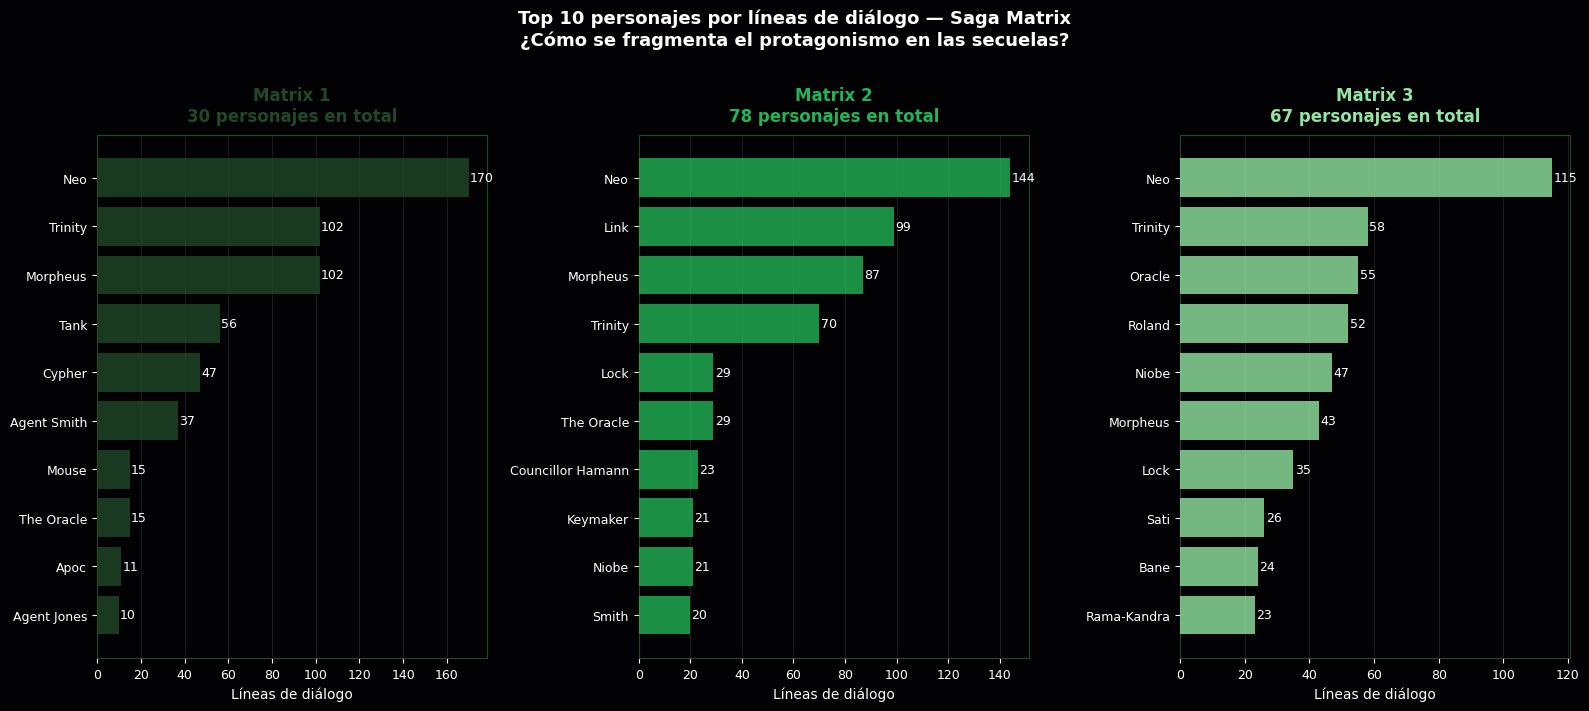

Gráfico personajes guardado


In [4]:
def top_personajes(df, n=10):
    """Top N personajes por número de líneas de diálogo."""
    return df.groupby('Character_Name').size().sort_values(ascending=True).tail(n)

top1 = top_personajes(m1)
top2 = top_personajes(m2)
top3 = top_personajes(m3)

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
fig.patch.set_facecolor('#020204')

datos = [
    (top1, 'Matrix 1', '#204829', f'{pers1} personajes en total'),
    (top2, 'Matrix 2', '#22b455', f'{pers2} personajes en total'),
    (top3, 'Matrix 3', '#92e5a1', f'{pers3} personajes en total'),
]

for ax, (top, titulo, color, subtitulo) in zip(axes, datos):
    ax.set_facecolor('#020204')
    bars = ax.barh(top.index, top.values, color=color, alpha=0.80, zorder=3)

    # Etiquetas de valor
    for bar, val in zip(bars, top.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=9, color='white')

    ax.set_title(f'{titulo}\n{subtitulo}',
                 fontsize=12, fontweight='bold', color=color, pad=10)
    ax.set_xlabel('Líneas de diálogo', fontsize=10, color='white')
    ax.tick_params(colors='white', labelsize=9)
    ax.spines[:].set_color('#204829')
    ax.grid(True, axis='x', alpha=0.10, color='white')

fig.suptitle('Top 10 personajes por líneas de diálogo — Saga Matrix\n'
             '¿Cómo se fragmenta el protagonismo en las secuelas?',
             fontsize=13, fontweight='bold', color='white', y=1.01)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'personajes_dialogo.png'), dpi=150,
            bbox_inches='tight', facecolor='#020204')
plt.show()
print('Gráfico personajes guardado')

---
## Gráfico 2 — Complejidad del guion vs Valoración IMDb

Comparativa de las métricas clave junto con la valoración del público.
Si la riqueza léxica es similar pero el número de personajes se dispara,
el problema no fue la calidad de la escritura sino la estructura narrativa.

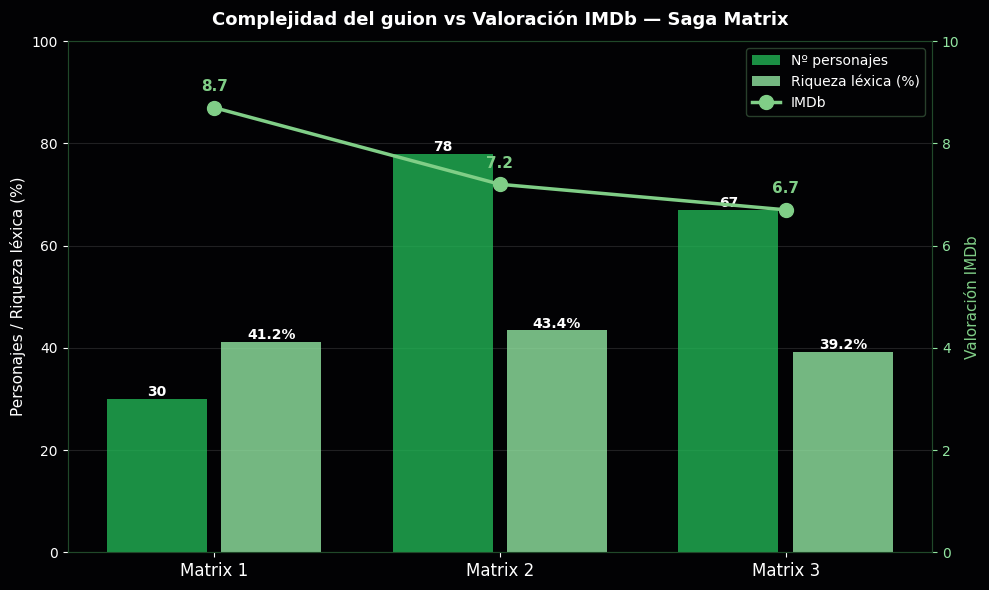

Gráfico complejidad guardado


In [5]:
peliculas = ['Matrix 1', 'Matrix 2', 'Matrix 3']
imdb = [8.7, 7.2, 6.7]
personajes = [pers1, pers2, pers3]
riqueza = [riqueza1, riqueza2, riqueza3]

fig, ax1 = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#020204')
ax1.set_facecolor('#020204')

x = range(3)
bars1 = ax1.bar([i - 0.2 for i in x], personajes, width=0.35,
                color='#22b455', alpha=0.80, label='Nº personajes', zorder=3)
bars2 = ax1.bar([i + 0.2 for i in x], riqueza, width=0.35,
                color='#92e5a1', alpha=0.80, label='Riqueza léxica (%)', zorder=3)

# Etiquetas en barras
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{int(bar.get_height())}', ha='center', fontsize=10, color='white', fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')

ax1.set_ylabel('Personajes / Riqueza léxica (%)', fontsize=11, color='white')
ax1.set_xticks(range(3))
ax1.set_xticklabels(peliculas, fontsize=12, color='white')
ax1.set_ylim(0, 100)
ax1.tick_params(colors='white')
ax1.spines[:].set_color('#204829')
ax1.grid(axis='y', alpha=0.12, color='white')

ax2 = ax1.twinx()
ax2.plot(range(3), imdb, color='#80ce87', linewidth=2.5,
         marker='o', markersize=10, label='IMDb', zorder=4)
ax2.set_ylabel('Valoración IMDb', fontsize=11, color='#80ce87')
ax2.set_ylim(0, 10)
ax2.tick_params(axis='y', colors='#92e5a1')
ax2.spines[:].set_color('#204829')

for i, v in enumerate(imdb):
    ax2.annotate(f'{v}', xy=(i, v), xytext=(0, 12),
                 textcoords='offset points', ha='center',
                 fontsize=11, color='#80ce87', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           fontsize=10, framealpha=0.3, facecolor='#020204',
           labelcolor='white', edgecolor='#80ce87', loc='upper right')

ax1.set_title('Complejidad del guion vs Valoración IMDb — Saga Matrix',
              fontsize=13, fontweight='bold', color='white', pad=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'complejidad_imdb.png'), dpi=150,
            bbox_inches='tight', facecolor='#020204')
plt.show()
print('Gráfico complejidad guardado')

---
## Gráfico 3 — Longitud de las frases: ¿diálogos más cortos en las secuelas?

Si Matrix 1 tenía grandes monólogos filosóficos y las secuelas se fragmentaron en
diálogos de acción más cortos, debería verse en la distribución de palabras por frase.
Analizamos las tres películas desde tres ángulos complementarios.

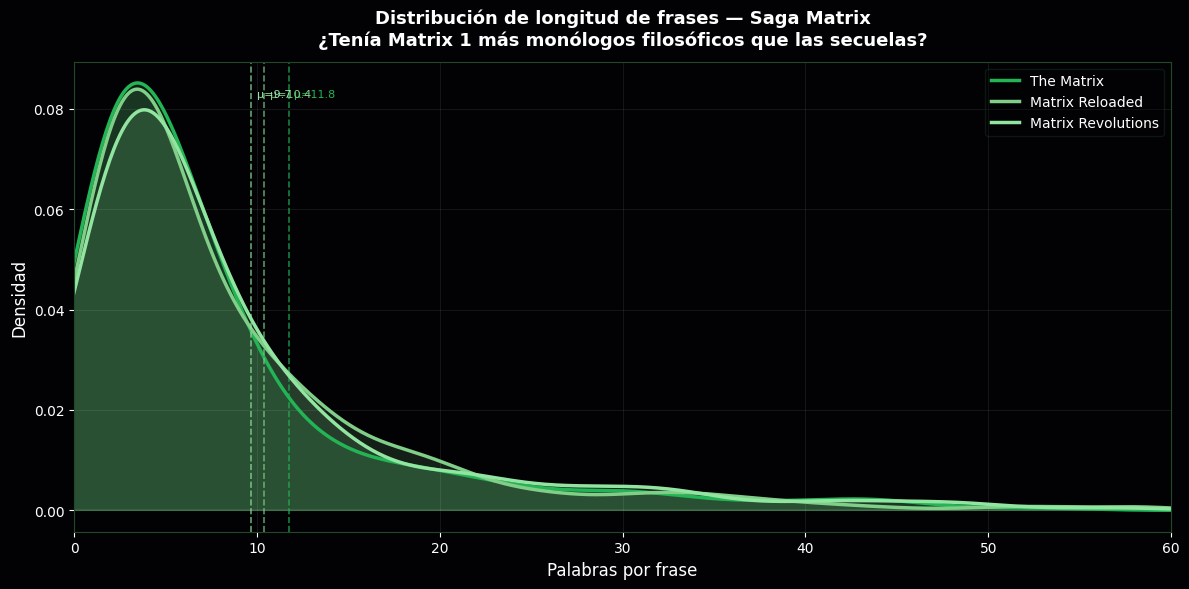

Gráfico KDE guardado


In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#020204')
ax.set_facecolor('#020204')

colores = {'The Matrix': '#22b455', 'Matrix Reloaded': '#80ce87', 'Matrix Revolutions': '#92e5a1'}

for df, pelicula, color in zip([m1, m2, m3], colores.keys(), colores.values()):
    datos = df['num_palabras'].dropna()
    datos[datos <= 60].plot.kde(ax=ax, color=color, linewidth=2.5, label=pelicula)
    ax.fill_between(ax.lines[-1].get_xdata(), ax.lines[-1].get_ydata(), alpha=0.15, color=color)
    ax.axvline(datos.mean(), color=color, linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(datos.mean() + 0.3, ax.get_ylim()[1] * 0.92, f'μ={datos.mean():.1f}',
            color=color, fontsize=8)

ax.set_xlim(0, 60)
ax.set_xlabel('Palabras por frase', fontsize=12, color='white')
ax.set_ylabel('Densidad', fontsize=12, color='white')
ax.set_title('Distribución de longitud de frases — Saga Matrix\n'
             '¿Tenía Matrix 1 más monólogos filosóficos que las secuelas?',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.tick_params(colors='white')
ax.spines[:].set_color('#204829')
ax.grid(True, alpha=0.08, color='white')

legend = ax.legend(fontsize=10, framealpha=0.3, facecolor='#020204',
                   labelcolor='white', edgecolor='#204829')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'longitud_A_kde.png'), dpi=150,
            bbox_inches='tight', facecolor='#020204')
plt.show()
print('Gráfico KDE guardado')

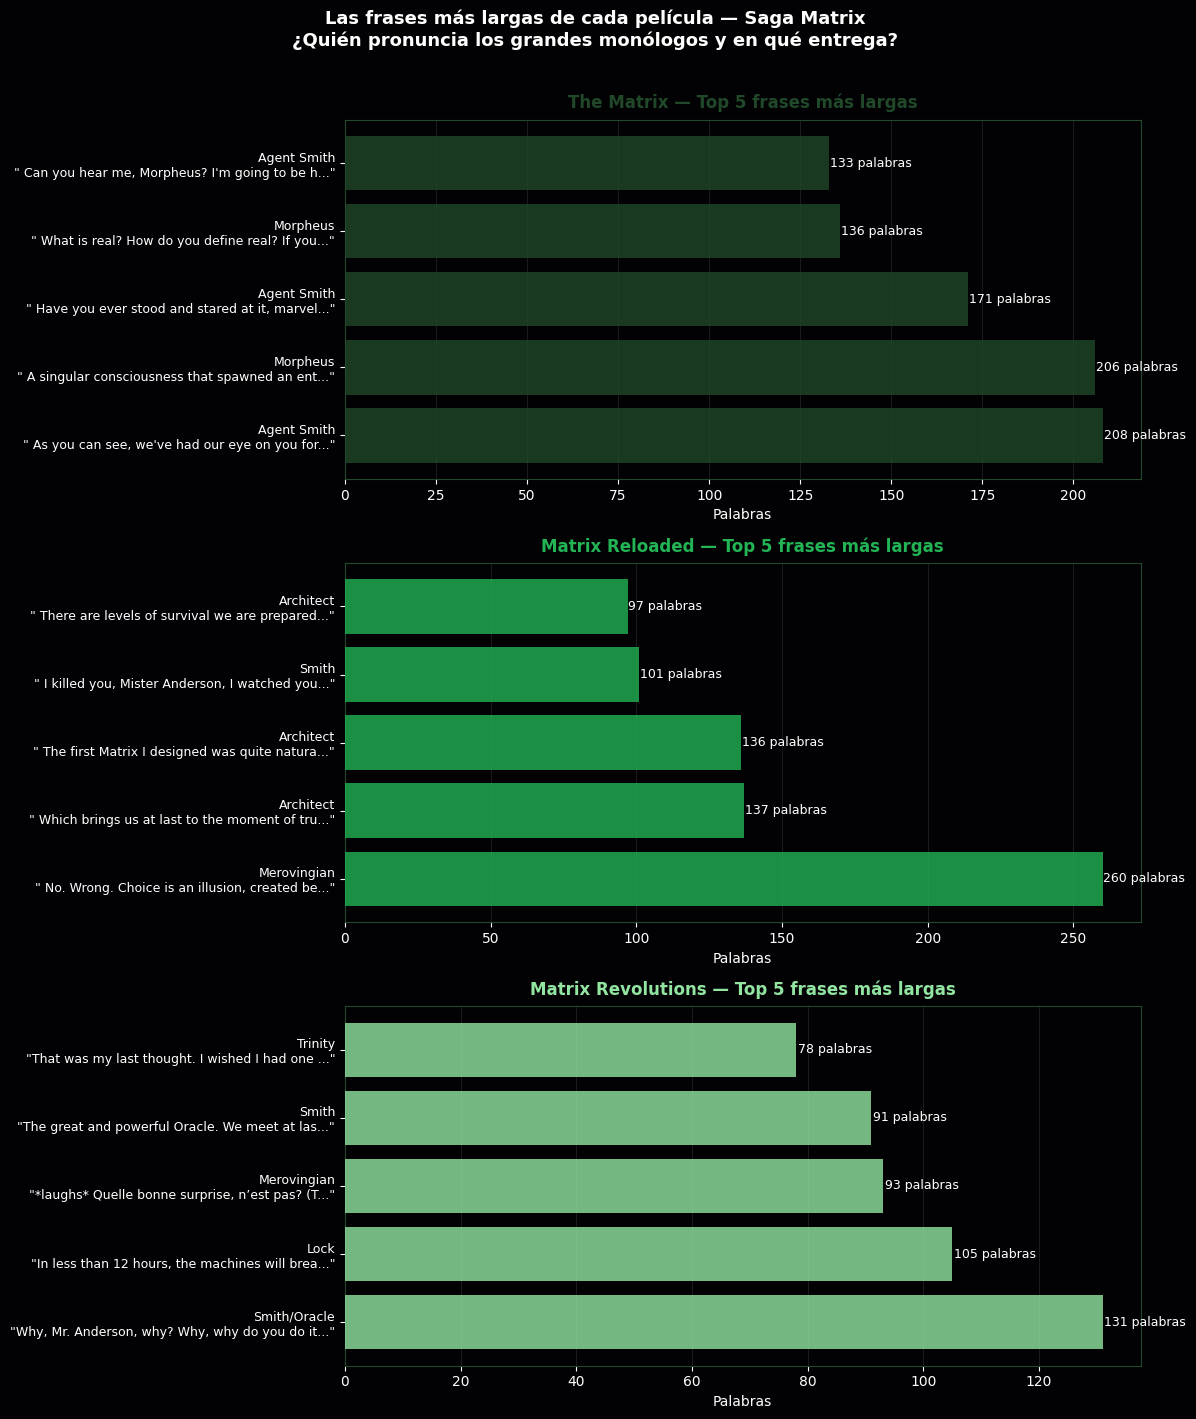

Gráfico B guardado


In [19]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.patch.set_facecolor('#020204')

for ax, top, pelicula, color in zip(axes, [top1, top2, top3], ['The Matrix','Matrix Reloaded','Matrix Revolutions'], ['#204829','#22b455','#92e5a1']):
    ax.set_facecolor('#020204')
    labels = [f"{row['Character_Name']}\n\"{str(row['Character_dialogue'])[:45]}...\"" for _, row in top.iterrows()]
    vals = top['num_palabras'].values
    bars = ax.barh(list(range(len(top))), vals, color=color, alpha=0.80, zorder=3)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val} palabras', va='center', fontsize=9, color='white')
    ax.set_yticks(list(range(len(top)))); ax.set_yticklabels(labels, fontsize=9, color='white')
    ax.set_xlabel('Palabras', fontsize=10, color='white')
    ax.set_title(f'{pelicula} — Top 5 frases más largas', fontsize=12, fontweight='bold', color=color, pad=8)
    ax.tick_params(colors='white'); ax.spines[:].set_color('#204829')
    ax.grid(True, axis='x', alpha=0.10, color='white')

fig.suptitle('Las frases más largas de cada película — Saga Matrix\n¿Quién pronuncia los grandes monólogos y en qué entrega?',
             fontsize=13, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'longitud_B_top_frases.png'), dpi=150, bbox_inches='tight', facecolor='#020204')
plt.show()
print('Gráfico B guardado')

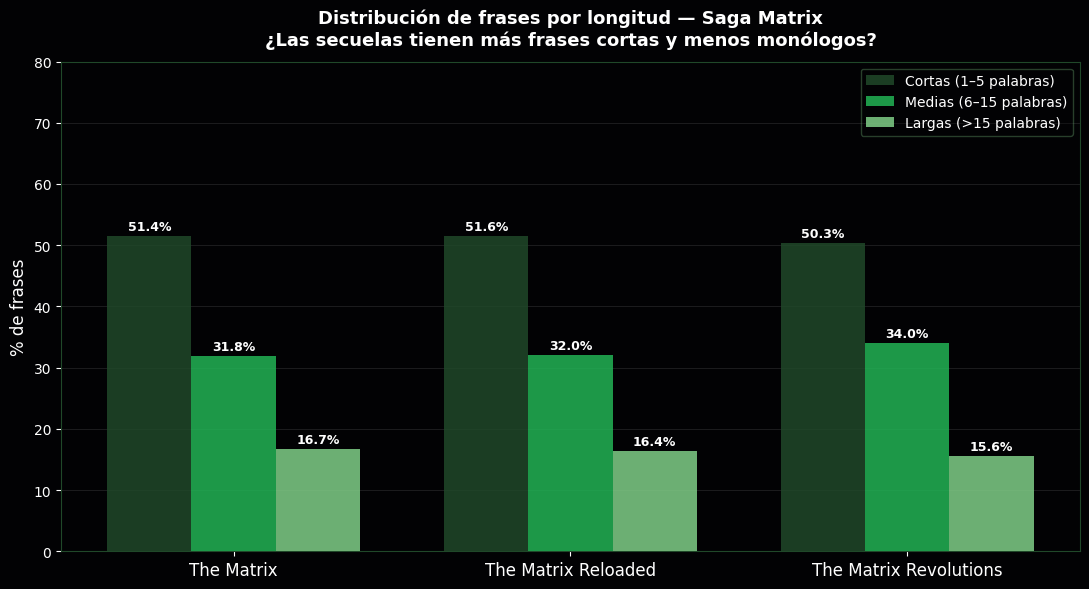

Gráfico C guardado


In [10]:
# C — Distribución por rangos de longitud
def rangos_pct(df):
    n = df['num_palabras']; total = len(n)
    return (n <= 5).sum()/total*100, ((n > 5) & (n <= 15)).sum()/total*100, (n > 15).sum()/total*100

r1 = rangos_pct(m1); r2 = rangos_pct(m2); r3 = rangos_pct(m3)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#020204'); ax.set_facecolor('#020204')

x = np.arange(3); ancho = 0.25
b1 = ax.bar(x - ancho, [r1[0],r2[0],r3[0]], ancho, color='#204829', alpha=0.85, label='Cortas (1–5 palabras)', zorder=3)
b2 = ax.bar(x,         [r1[1],r2[1],r3[1]], ancho, color='#22b455', alpha=0.85, label='Medias (6–15 palabras)', zorder=3)
b3 = ax.bar(x + ancho, [r1[2],r2[2],r3[2]], ancho, color='#80ce87', alpha=0.85, label='Largas (>15 palabras)', zorder=3)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}%',
                ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(['The Matrix','The Matrix Reloaded','The Matrix Revolutions'], fontsize=12, color='white')
ax.set_ylabel('% de frases', fontsize=12, color='white'); ax.set_ylim(0, 80)
ax.set_title('Distribución de frases por longitud — Saga Matrix\n¿Las secuelas tienen más frases cortas y menos monólogos?',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.tick_params(colors='white'); ax.spines[:].set_color('#204829')
ax.grid(True, axis='y', alpha=0.10, color='white')
ax.legend(fontsize=10, framealpha=0.3, facecolor='#020204', labelcolor='white', edgecolor='#80ce87')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'longitud_C_rangos.png'), dpi=150, bbox_inches='tight', facecolor='#020204')
plt.show()
print('Gráfico C guardado')

---
## Conclusiones Hipótesis 3

El análisis de los tres guiones de la saga revela una conclusión sorprendente y contraintuitiva:
**las secuelas no fallaron por mala escritura, sino por exceso de ella.**

**El arco emocional** es la evidencia más clara. Matrix 1 tiene una curva narrativa definida —
un protagonista que parte de la confusión, atraviesa el conflicto y alcanza la resolución.
Las secuelas presentan un arco mucho más plano y ruidoso, sin una dirección emocional clara.
Esto no se mide en vocabulario, se mide en estructura.

**El reparto de diálogos** confirma la dispersión: Matrix 1 tiene un protagonista claro (Neo)
que concentra la mayor parte de los diálogos, con Morfeo y Trinity como apoyos definidos.
En las secuelas el protagonismo se fragmenta entre decenas de personajes — Matrix 2 llega
a tener más del doble de personajes con voz que la primera entrega.

**La riqueza léxica**, sin embargo, es prácticamente idéntica en las tres películas.
El vocabulario no se volvió más simple ni más difícil. Los guionistas no perdieron
calidad de escritura — perdieron foco narrativo.

**La valoración IMDb** (8.7 → 7.2 → 6.7) cae en paralelo al aumento de personajes,
no al cambio en riqueza léxica. La correlación está en la dispersión, no en la complejidad.

Conclusión: lo que desconectó al público de las secuelas no fue que los diálogos
fueran peores, sino que había demasiados personajes hablando y ninguno con el peso
narrativo suficiente para anclar la historia. Matrix 1 era la historia de Neo.
Las secuelas eran la historia de todos y de nadie.